# Retrieval-Augmented Generation (RAG) architecture

Dark Data PM Analyst challenge, built on a real municipal work-order export.

| | |
|---|---|
| Work orders | 37,778 |
| Asset attachments | 867,448 |
| Notes | 33,572 |
| Window | 2008 to 2023 |

A Cityworks dump from a city Public Works and Facilities department: water, sewer,
streets, traffic, electric and buildings.

The failure patterns are buried in the note text. No column states them.

**There is no answer key.** Nothing here tells you which work orders belong to the
same problem, or how any of them turned out. Working that out is the challenge.

---

### Setup

```
pip install -r requirements.txt
```

Then run the cells in order. What is in this folder:

```
aisa_challenge.ipynb    this notebook
challenge.md            the brief: what to build and what to watch out for
requirements.txt        dependencies
secrets.json            put your Google AI Studio key here (section 9)
data/                   WORKORDER.csv, WOENTITY.csv, WOCOMMENT.csv
pdfs/                   maintenance procedure documents (section 11)
```

Sections 1 to 8 run offline. Sections 9, 10 and 11 need a free API key.

The first run downloads the embedding model (about 400 MB) and takes a few minutes
in section 2. After that it is cached.

## 1. Load and Understand the Work Order Dark Data

Three CSV files in `data/`.

| File | Rows | What it is |
|---|---|---|
| `WORKORDER.csv` | 37,778 | One row per job |
| `WOENTITY.csv` | 867,448 | Which assets each job touched |
| `WOCOMMENT.csv` | 33,572 | What people wrote. This is the dark data |

### The two grains

```
work order  ->  assets touched   (1 to 14,232)
work order  ->  note             (0 or 1)
```

A job is not an asset. `WOENTITY` is the bridge between them, and joining through it
gives one row per **work order x asset**. That is the grain used below.

### The asset key

`EntityUid` alone is **not** unique. The same number means different things under
different `EntityType` values. The key is `EntityType` + `EntityUid` together.

`ApplyToEntity` on the work order looks like the asset but is not. It is the job
template's intended class, and it often disagrees with what was actually attached.

### The columns

| Column | What it is |
|---|---|
| `InitiateDate` | when the job was opened |
| `Description` | the job template's title, not a note |
| `Shop` | the crew that owns the work: WATER, FACILITY, TRAFFIC, STREETS ... |
| `AssetGroup` | the program: Water Distribution, Sanitary Sewer, Electric ... |
| `Priority` | 1 to 6, set at intake |
| `WOAddress` | the site |
| `Comments` | the note |

### One property of the text

**No record explains its own cause.** A crew writes what they found and what they
did. Nobody writes "premature bearing wear from lubrication contamination". Finding
a cause means reading several notes about one asset and concluding something no
single record states.

The cell below loads the three files and joins them. It does not clean or repair
anything. Missing values stay missing, because that is what the data looks like.

In [1]:
import pandas as pd

DATA_DIR = 'data'

WO_COLS = ['WorkOrderId', 'InitiateDate', 'Description', 'Shop', 'AssetGroup',
           'Priority', 'WOAddress', 'Location', 'Status', 'IsReactive',
           'Text10', 'ApplyToEntity']

wo = pd.read_csv(f'{DATA_DIR}/WORKORDER.csv', low_memory=False,
                 encoding='utf-8-sig', dtype=str, usecols=WO_COLS)
en = pd.read_csv(f'{DATA_DIR}/WOENTITY.csv', low_memory=False,
                 encoding='utf-8-sig', dtype=str,
                 usecols=['WorkOrderId', 'EntityType', 'EntityUid'])
cm = pd.read_csv(f'{DATA_DIR}/WOCOMMENT.csv', low_memory=False,
                 encoding='utf-8-sig', dtype=str,
                 usecols=['CommentId', 'WorkOrderId', 'Comments'])

print(f'WORKORDER {len(wo):>7,} rows   work order headers')
print(f'WOENTITY  {len(en):>7,} rows   assets attached to those work orders')
print(f'WOCOMMENT {len(cm):>7,} rows   dispatcher and crew notes')

cm['seq'] = pd.to_numeric(cm['CommentId'], errors='coerce')
cm = cm.sort_values('seq')

notes = {}
for wid, body in zip(cm['WorkOrderId'], cm['Comments']):
    if wid not in notes:
        notes[wid] = []
    notes[wid].append(str(body))
for wid in notes:
    notes[wid] = ' '.join(notes[wid])

en['asset_key'] = en['EntityType'] + '|' + en['EntityUid']
en['n_assets_on_wo'] = en['WorkOrderId'].map(en.groupby('WorkOrderId').size())

hist = en.merge(wo, on='WorkOrderId', how='left')
hist['initiated'] = pd.to_datetime(hist['InitiateDate'], errors='coerce', utc=True)
hist['text'] = hist['WorkOrderId'].map(notes)
hist = hist.sort_values('initiated').reset_index(drop=True)

jobs = hist.drop_duplicates('WorkOrderId')

print()
print(f'joined: {len(hist):,} rows, one per work order x asset')
print(f'  work orders             {hist["WorkOrderId"].nunique():>9,}')
print(f'  distinct assets         {hist["asset_key"].nunique():>9,}')
print(f'  work orders with a note {jobs["text"].notna().sum():>9,}')
print()
print('No answer key. Nothing here says which work orders belong to the same')
print('problem, or how any of them turned out.')

hist.head()

WORKORDER  37,778 rows   work order headers
WOENTITY  867,448 rows   assets attached to those work orders
WOCOMMENT  33,572 rows   dispatcher and crew notes

joined: 867,448 rows, one per work order x asset
  work orders                37,772
  distinct assets            75,058
  work orders with a note    33,459

No answer key. Nothing here says which work orders belong to the same
problem, or how any of them turned out.


,WorkOrderId,EntityType,EntityUid,asset_key,n_assets_on_wo,ApplyToEntity,AssetGroup,Description,InitiateDate,IsReactive,Location,Priority,Shop,Status,Text10,WOAddress,initiated,text
0,136065,WWTPSTRUCTURE,OE19,WWTPSTRUCTURE|OE19,1,WWTPSTRUCTURE,wwtp Facility,Improvements,1970-01-01T00:00:00Z,False,Phase 2 East Clarifier,3,NaN,CLOSED,NaN,OE19,1970-01-01 00:00:00+00:00,NaN
1,135992,TPAVEDROADS,1846,TPAVEDROADS|1846,1,TPAVEDROADS,Streets,Pavement Inspection,1980-01-01T07:00:00Z,False,2487 RAQUEL RD,5,NaN,CLOSED,NaN,NaN,1980-01-01 07:00:00+00:00,NaN
2,135988,TPAVEDROADS,1844,TPAVEDROADS|1844,1,TPAVEDROADS,Streets,Pavement Inspection,1980-01-01T07:00:00Z,False,2485 MARK RD,5,NaN,CLOSED,NaN,NaN,1980-01-01 07:00:00+00:00,NaN
3,134228,SWINLET,3572,SWINLET|3572,1,SWINLET,Stormwater,Clean,1982-03-28T07:00:00Z,True,,3,STORM,CLOSED,NaN,NaN,1982-03-28 07:00:00+00:00,NaN
4,134229,SWINLET,3572,SWINLET|3572,1,SWINLET,Stormwater,Clean,1982-03-29T00:04:00Z,True,,3,STORM,CLOSED,NaN,NaN,1982-03-29 00:04:00+00:00,NaN


In [2]:
wo_level = hist.drop_duplicates('WorkOrderId')

print(f'--- work order level ({len(wo_level):,} jobs) ---')
print()
print('Shop:')
print(wo_level['Shop'].value_counts(dropna=False).head(8))
print()
print('AssetGroup:')
print(wo_level['AssetGroup'].value_counts(dropna=False).head(8))
print()
print('Priority:')
print(wo_level['Priority'].value_counts(dropna=False).sort_index())
print()
print(f"work orders with a note: {wo_level['text'].notna().sum():,} of {len(wo_level):,}")
print(f"distinct Description   : {wo_level['Description'].nunique():,}")
print()
print('note length in characters:')
print(wo_level['text'].str.len().describe()[['min', '50%', 'max']].round(0).to_string())
print()

print(f'--- asset level ({len(hist):,} work order x asset rows) ---')
print()
print('nulls per column (%):')
print((hist.isnull().mean() * 100).round(1).sort_values().to_string())
print()
for c in ['asset_key', 'EntityType', 'WOAddress']:
    print(f'  {c:<12} {hist[c].nunique():>9,} distinct')
print()
print('assets per work order:')
print(hist.groupby('WorkOrderId')['asset_key'].nunique()
          .describe()[['min', '50%', 'max']].to_string())
print()
print('work orders per asset:')
wo_per_asset = hist.groupby('asset_key')['WorkOrderId'].nunique()
for k in [2, 3, 5, 10]:
    print(f'  {(wo_per_asset >= k).sum():>7,} assets have {k} or more')
print()

print('work orders per year:')
print(wo_level.groupby(wo_level['initiated'].dt.year).size().to_string())

--- work order level (37,772 jobs) ---

Shop:
Shop
WATER       7965
FACILITY    6440
TRAFFIC     4380
STREETS     4295
WASTEWTR    3722
ELECTRIC    3563
XTA         2457
SIGN        2024
Name: count, dtype: int64

AssetGroup:
AssetGroup
Planning & Dev         9966
Water Distribution     7937
Electric               5431
Traffic                4715
Sanitary Sewer         3826
Streets                2806
Stormwater             1064
Facility Management     612
Name: count, dtype: int64

Priority:
Priority
1       1002
2        489
3      35938
4         57
5        195
6          5
NaN       86
Name: count, dtype: int64

work orders with a note: 33,459 of 37,772
distinct Description   : 376

note length in characters:
min       2.0
50%     152.0
max    3172.0

--- asset level (867,448 work order x asset rows) ---

nulls per column (%):
WorkOrderId        0.0
EntityType         0.0
EntityUid          0.0
asset_key          0.0
n_assets_on_wo     0.0
ApplyToEntity      0.0
AssetGroup        

### Reading that output

**Counts are reported per work order, not per row.** One job can attach 14,232
assets, so counting rows on the joined frame counts assets touched, not work done.
Count rows by mistake and `Shop` reads SIGN 574,674, which is wrong. At job level
the biggest shop is WATER at 7,965.

**`Priority` is dead.** About 95% of work orders are priority `3`. It is a default
nobody changed. Do not build features on it.

**`Description` is a template title, not a note.** 376 distinct values across 37,778
jobs: `Water Meter Change Out`, `FM HVAC PM`, `Repair Scheduled`. It tells you what
kind of job was raised, never what was found.

**About 4,300 work orders have no note**, and many that do are one line.

**The dates contain sentinels.** `InitiateDate` runs from 1970 to 2222. Nothing has
been dropped. Filter before any time-series work. Most of the corpus is 2008 to 2010.

### What the notes look like

```
From: Request ID: 117600, 03/09/2009 4:29:22 PM
HEATING/AIR COND
Problem Details: A/C running but not producing cold air.
Problem Comments:
By KING, ROBIN: 03/09/2009 4:19:47 PM A/C running but not producing cold air.
By MOORE, CYNTHIA: 03/13/2009 9:41:16 AM 03/10/09 - Will need to wait for a warmer day
```

A dispatcher intake block, then dated crew entries appended over time. Two things
follow from that:

- The `From: Request ID:` header is on most notes. Identical text on thousands of
  records pulls them together for reasons that have nothing to do with the fault.
- Employee names are in the text. That is PII, and it matters before you send any of
  this to an external model.

## 2. Building the Embedding Space

Convert each note into a vector with `sentence-transformers/all-mpnet-base-v2`,
loaded the same way as the DISES pipeline:
`HuggingFaceEmbeddings(model_name=..., model_kwargs={'device': 'cpu'})`.

### One note per work order, not one per row

`hist` has one row per work order x asset, so a job touching six assets repeats its
note six times. Embedding that frame would compute the same vector over and over and
let one job dominate its own neighbourhood. So this section drops back to one row per
work order that has a note.

### Embed the note, not `Description`

`Description` is a template title and there are only 376 of them. Adding it would
mostly encode which template was used, which is a label leaking into the input.

### Why `SAMPLE_N` is mandatory

Section 5 computes a full pairwise similarity matrix. For `n` documents that is
`n x n` float64 values, or `8n^2` bytes:

| n | matrix size |
|---|---|
| 6,000 | 288 MB |
| 20,000 | 3.2 GB |
| 33,460 | **9.0 GB** |

The sample is a hard requirement, not a speed shortcut. Sampling is stratified by
`Shop` so crew proportions are preserved. Sections 6 and 7 run on the full frame,
because repeat visits are what sampling destroys.

In [3]:
import numpy as np
from langchain_community.embeddings import HuggingFaceEmbeddings

SAMPLE_N = 6000

notes_df = hist.drop_duplicates('WorkOrderId').dropna(subset=['text']).reset_index(drop=True)
print(f'{len(notes_df):,} work orders carry a note')

if SAMPLE_N and SAMPLE_N < len(notes_df):
    frac = SAMPLE_N / len(notes_df)
    picked = []
    for shop, g in notes_df.groupby('Shop', dropna=False):
        n_take = max(1, int(round(len(g) * frac)))
        picked.extend(g.sample(n_take, random_state=200).index)
    work = notes_df.loc[picked].reset_index(drop=True)
    print(f'working on a stratified sample of {len(work):,} notes '
          f'({len(work) / len(notes_df):.1%} of those available)')
else:
    work = notes_df.reset_index(drop=True)
    print(f'working on all {len(work):,} notes')

print('Initializing Embedding Model...')
# can also use 'all-MiniLM-L6-v2'rather than 'all-mpnet-base-v2' for a smaller model
emb_mpnet = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-mpnet-base-v2',
    model_kwargs={'device': 'cpu'}
)

texts = work['text'].astype(str).tolist()
embeddings = np.array(emb_mpnet.embed_documents(texts))

print(embeddings.shape)

C:\Users\ramos\AppData\Local\Temp\ipykernel_18156\888735382.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings


33,459 work orders carry a note
working on a stratified sample of 6,003 notes (17.9% of those available)
Initializing Embedding Model...


C:\Users\ramos\AppData\Local\Temp\ipykernel_18156\888735382.py:23: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  emb_mpnet = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

(6003, 768)


## 3. Visualizing the Embedding Space

Each vector has 768 dimensions. PCA projects onto the two directions carrying the
most variance so it can be drawn.

### What the plot can and cannot tell you

The printed line at the bottom is the important one: two components capture only a
fraction of the total variance. The rest is not on the screen.

Clusters that overlap here may be cleanly separated along any of the 766 discarded
directions. A 2D picture holding a small share of the information is not evidence
about separability in either direction. Section 5 measures it properly.

### What to expect from this corpus

Two things drive variance that have nothing to do with the fault:

- **The dispatcher header.** Most notes open with the same scaffold. Identical
  boilerplate on thousands of records pulls them together.
- **Note length.** Notes run from 1 to 3,172 characters. A one-line entry and a note
  with six months of appended updates land far apart even for the same asset.

If the plot is one dense blob, that is the boilerplate. Stripping the header before
embedding is a reasonable experiment.

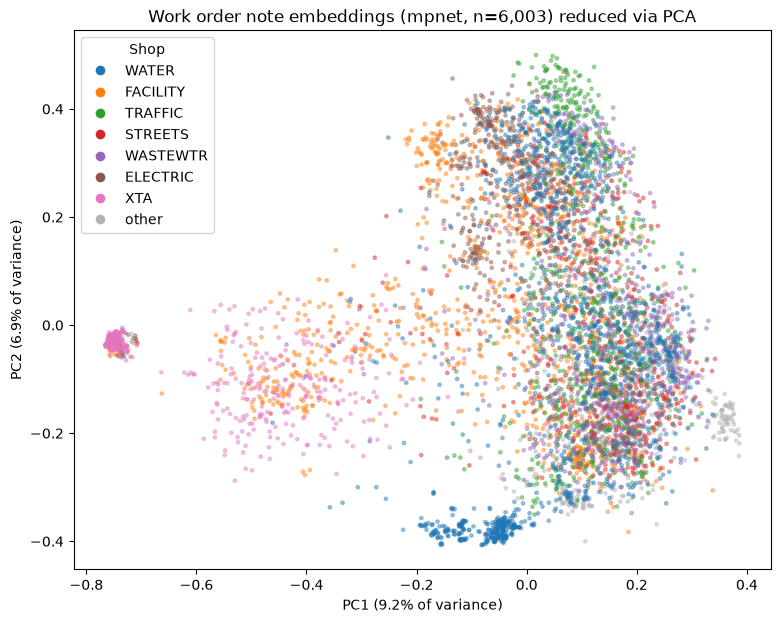

two components capture 16.0% of total variance


In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=200)
coords = pca.fit_transform(embeddings)
work['pca_x'], work['pca_y'] = coords[:, 0], coords[:, 1]

TOP_N = 7
top_shops = work['Shop'].value_counts().head(TOP_N).index.tolist()

shop_plot = []
for s in work['Shop']:
    if s in top_shops:
        shop_plot.append(s)
    else:
        shop_plot.append('other')
work['shop_plot'] = shop_plot

palette = plt.get_cmap('tab10')
color_map = {}
for i, s in enumerate(top_shops):
    color_map[s] = palette(i)
color_map['other'] = (0.7, 0.7, 0.7, 1.0)

point_colors = [color_map[s] for s in work['shop_plot']]

plt.figure(figsize=(9, 7))
plt.scatter(work['pca_x'], work['pca_y'], c=point_colors, s=6, alpha=0.4)
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=l)
           for l, c in color_map.items()]
plt.legend(handles=handles, title='Shop')
plt.title(f'Work order note embeddings (mpnet, n={len(work):,}) reduced via PCA')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} of variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} of variance)')
plt.show()

print(f'two components capture {pca.explained_variance_ratio_.sum():.1%} of total variance')

## 4. What the Embedding Space Actually Represents

`all-mpnet-base-v2` is a `sentence-transformers` model. On top of the MPNet backbone
sits a trained pooling layer that mean-pools the **last** hidden state across tokens,
weighted by the attention mask so padding contributes nothing:

$$
e_i = \frac{\sum_{j=1}^{L} H_{i,j,:} \cdot m_{i,j}}{\sum_{j=1}^{L} m_{i,j}}
$$

where $H \in \mathbb{R}^{B \times L \times D}$ is the last hidden state, $D = 768$,
$m$ is the attention mask, $B$ is the number of input texts and $L$ the token length.
One $D$-dimensional vector $e_i$ per row, stored in `embeddings`.

This pools the last layer, not the penultimate one. Penultimate-layer pooling is an
older manual technique and does not apply to a `sentence-transformers` model, which
was fine-tuned with its pooling head attached.

### Why cosine similarity and not Euclidean distance

The contrastive training objective optimizes the model so that

$$
\cos(e_i, e_j) = \frac{e_i \cdot e_j}{\|e_i\| \|e_j\|}
$$

is high for semantically similar text and low otherwise. Nothing in training
constrains vector magnitude, so Euclidean distance mixes semantic difference with
length effects. Everything below uses cosine.

### Two consequences for this corpus

**Mean pooling weights every token equally.** A note with months of appended crew
entries and a one-line note about the same asset do not land in the same place.

**The model truncates at 384 tokens.** Anything past that is dropped silently. On the
longest notes, the closing entry that says what finally fixed the problem is exactly
what gets cut.

## 5. Does the Text Alone Predict the Shop?

Can the note alone tell you which crew owns the job?

`Shop` is set on the work order, not written in the note, so it is a fair held-out
label. There are about 25 of them: WATER, FACILITY, TRAFFIC, STREETS, WASTEWTR,
ELECTRIC and the rest.

### Method

Leave-one-out k-nearest-neighbour over cosine similarity.

1. Compute the full `n x n` cosine similarity matrix.
2. Set the diagonal to `-1` so a row can never match itself. That is what makes it
   leave-one-out.
3. For each row take the `k = 5` most similar other rows, majority-vote their `Shop`.
4. Confidence is the mean similarity of the rows that voted for the winner.

No training, no LLM call. The baseline to beat is the majority class, printed by the
cell.

### What makes this hard here

- **25 classes.** More ways to be wrong, and a low majority baseline.
- **The classes overlap.** WATER and WASTEWTR both dig up streets and write about
  excavation and backfill. XTA is administrative and can carry anything.
- **Shared boilerplate.** Every note opens with the same dispatcher scaffold, which
  is similarity carrying no crew information at all.

### The confidence curve is the useful part

Watch the last table rather than the headline number. If accuracy rises with mean
top-k similarity, the score is a real confidence signal and you can put a threshold
on it: handle confident rows cheaply, send the rest to an LLM. Pick the cut from that
curve, not from intuition.

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

K = 5
sims = cosine_similarity(embeddings)
np.fill_diagonal(sims, -1.0)

truth = work['Shop'].fillna('(none)').to_numpy()
pred, conf = [], []
for row in sims:
    top_k = row.argsort()[-K:][::-1]
    labels, scores = truth[top_k], row[top_k]
    vals, counts = np.unique(labels, return_counts=True)
    winner = vals[counts.argmax()]
    pred.append(winner)
    conf.append(scores[labels == winner].mean())

work['shop_truth'] = truth
work['pred_Shop'] = pred
work['pred_confidence'] = conf

acc = (work['pred_Shop'] == work['shop_truth']).mean()
base = work['shop_truth'].value_counts(normalize=True).max()
print(f'leave-one-out {K}-NN accuracy: {acc:.1%}   (majority-class baseline {base:.1%})')
print()

print('per-class accuracy (shops with 50 or more notes):')
for s in work['shop_truth'].value_counts().index:
    sub = work[work['shop_truth'] == s]
    if len(sub) >= 50:
        print(f'  {s:<12} {(sub["pred_Shop"] == s).mean():>6.1%}   (n={len(sub):,})')
print()

print('most common confusions (truth -> predicted):')
wrong = work[work['pred_Shop'] != work['shop_truth']]
print(wrong.groupby(['shop_truth', 'pred_Shop']).size()
           .sort_values(ascending=False).head(10).to_string())
print()

print('accuracy by confidence band:')
bands = pd.cut(work['pred_confidence'], [0, .4, .5, .6, .7, 1.0])
print((work['pred_Shop'] == work['shop_truth']).groupby(bands, observed=False)
      .agg(['mean', 'size']))

leave-one-out 5-NN accuracy: 90.7%   (majority-class baseline 22.3%)

per-class accuracy (shops with 50 or more notes):
  WATER         96.3%   (n=1,339)
  FACILITY      90.7%   (n=1,120)
  TRAFFIC       95.1%   (n=778)
  STREETS       91.0%   (n=688)
  WASTEWTR      86.5%   (n=608)
  ELECTRIC      83.9%   (n=545)
  XTA           83.2%   (n=440)
  SIGN          95.6%   (n=360)
  FIELDSVC      68.5%   (n=73)

most common confusions (truth -> predicted):
shop_truth  pred_Shop
ELECTRIC    XTA          43
XTA         ELECTRIC     38
            FACILITY     32
ELECTRIC    TRAFFIC      30
WASTEWTR    WATER        30
FACILITY    TRAFFIC      27
            XTA          21
TRAFFIC     FACILITY     20
WASTEWTR    STREETS      20
FACILITY    WASTEWTR     15

accuracy by confidence band:
                     mean  size
pred_confidence                
(0.0, 0.4]       0.125000     8
(0.4, 0.5]       0.608696    69
(0.5, 0.6]       0.715426   376
(0.6, 0.7]       0.820672   803
(0.7, 1.0]       0.

### Reading the misclassifications

Cross-shop confusion is often not an error. A sewer backup that floods a basement
reads as both WASTEWTR and FACILITY. A streetlight hit by a vehicle involves STREETS
and ELECTRIC. The label records which crew was dispatched, which is an operational
decision, not a property of the text.

Two to look for in the table above:

- **WATER against WASTEWTR.** Both dig up streets and share most of their vocabulary.
- **Anything against XTA.** XTA is administrative overhead with no consistent subject.

Read a handful individually rather than only counting them. A record that looks like
the wrong shop may be the most interesting one in the file.

## 6. Asset Histories

Every section so far treats a work order as an independent document. That is the
mistake the challenge is about. The value is in the sequence: one asset visited
several times over months or years, each note unremarkable alone, together describing
a problem nobody joined up.

No machine learning here. Group by asset, sort by time, print it and read it.

### Three things the cell does

**Keys on `EntityType` + `EntityUid`.** A real global asset id, already built as
`asset_key`.

**Drops the inventory sweeps.** A job that attached 14,232 signs did not inspect any
one of them. `BULK_CAP` removes jobs above a threshold. This is the only place the
notebook filters anything, and it is done here rather than at load so the raw join
stays intact.

**Runs on the full frame.** Sampling breaks sequences apart.

### Two kinds of asset

`EntityType` tells you which you have:

- **Equipment** - SSGRAVITYMAIN, E_STREETLIGHT, TSIGNALCABINET, SSMANHOLE, WHYDRANT.
  Repeat visits mean recurring trouble with one physical thing.
- **Locations** - ADDRESSES, CITYFACILITIES, STREETSTRAFFIC, CITY_DEPTS. Repeat
  visits may be unrelated work at the same place: janitorial, then HVAC, then paint.

Neither is filtered out. For water and sewer service work an address genuinely is the
thing that recurs, so dropping locations would lose real evidence. `asset_class` is
added as a column so you can split them when you want to.

### What to look for

- Does the language escalate? "within tolerance", then "still not right", then "would not restart"
- Are the gaps organic, or regular? Regular usually means a PM cycle, not a fault
- Does the last record name a part and a verification, or trail off?
- Does a "repair complete" note get followed by the same complaint days later?

In [6]:
import textwrap

BULK_CAP = 10

LOCATION_TYPES = {'ADDRESSES', 'CITYFACILITIES', 'CITY FACILITIES',
                  'CITY_DEPTS', 'STREETSTRAFFIC'}

seq = hist[hist['n_assets_on_wo'] <= BULK_CAP].copy()

asset_class = []
for t in seq['EntityType']:
    if t in LOCATION_TYPES:
        asset_class.append('location')
    else:
        asset_class.append('equipment')
seq['asset_class'] = asset_class

wo_per_asset = seq.groupby('asset_key')['WorkOrderId'].nunique()
repeat = wo_per_asset[wo_per_asset >= 3].sort_values(ascending=False)

print(f'bulk cap {BULK_CAP}: kept {seq["WorkOrderId"].nunique():,} work orders '
      f'and {seq["asset_key"].nunique():,} assets')
print(f'{len(repeat):,} assets have 3 or more work orders')
print(f'longest history: {repeat.max():,} work orders on {repeat.index[0]}')
print('  (that one is a catch-all record, not an asset -- see the next section)')
print()
print('those assets by class:')
print(seq[seq['asset_key'].isin(repeat.index)]
        .drop_duplicates('asset_key')['asset_class'].value_counts().to_string())
print()
print('those assets by EntityType:')
print(seq[seq['asset_key'].isin(repeat.index)]
        .drop_duplicates('asset_key')['EntityType'].value_counts().head(10).to_string())
print()


def timeline(asset_key, width=95):
    sub = seq[seq['asset_key'] == asset_key].drop_duplicates('WorkOrderId')
    sub = sub.sort_values('initiated')
    print('=' * width)
    print(f'{asset_key}   ({len(sub)} work orders)')
    print('=' * width)
    prev = None
    for _, r in sub.iterrows():
        if prev is None:
            gap = 'start'
        else:
            gap = f'+{(r["initiated"] - prev).days}d'
        prev = r['initiated']
        print(f'{r["WorkOrderId"]} | {str(r["initiated"])[:10]} | {gap:>7} | '
              f'{str(r["Shop"]):<9} | P{r["Priority"]}')
        print(f'    {r["Description"]}')
        note = r['text']
        if isinstance(note, str):
            for line in textwrap.wrap(' '.join(note.split()), width - 6)[:6]:
                print(f'    {line}')
        else:
            print('    (no note on this work order)')
        print()


timeline('CITYFACILITIES|130')

readable = repeat[(repeat >= 4) & (repeat <= 8)]
equipment = set(seq[seq['asset_class'] == 'equipment']['asset_key'])

shown = 0
for a in readable.index:
    if a in equipment:
        timeline(a)
        shown += 1
    if shown == 2:
        break

bulk cap 10: kept 34,632 work orders and 26,423 assets
2,680 assets have 3 or more work orders
longest history: 3,766 work orders on CITYFACILITIES|642
  (that one is a catch-all record, not an asset -- see the next section)

those assets by class:
asset_class
location     1526
equipment    1154

those assets by EntityType:
EntityType
STREETSTRAFFIC    874
ADDRESSES         539
SSGRAVITYMAIN     338
E_STREETLIGHT     167
TSIGNALCABINET     93
SSMANHOLE          86
CITYFACILITIES     70
WHYDRANT           66
SWINLET            47
CITY_DEPTS         41

CITYFACILITIES|130   (4 work orders)
109082 | 2008-12-02 |   start | FACILITY  | P3
    FM HVAC
    From: Request ID: 114371, 12/02/2008 2:24:44 PMFM - Heating/Air Cond Problems Problem
    Details: Need help with heater in the Old Narcotic House .. Next door to 7000 E 2nd St
    Problem Comments: By HISEY, ANDREA: 12/02/2008 2:23:08 PM 12/2/08 - Need help with heater
    in the Old Narcotic House .. Next door to 7000 E 2nd St By ISBELL, 

### Splitting a history into episodes

An asset with 12 work orders over 15 years is not one problem. It is several,
separated by long quiet stretches. Nothing in the data says where one ends and the
next begins, so you have to decide.

The cheapest defensible rule is a time gap: consecutive work orders on the same asset
belong to the same episode unless more than `GAP_DAYS` have passed.

**It is a starting point, not an answer.** 180 days is a guess. Two failures three
weeks apart may be unrelated; a slow problem may go quiet for two years and come
back. The honest way to pick the number is to segment, read a dozen results, and
adjust. That is what the printed distribution is for.

Other rules worth trying: consecutive orders sharing a `Shop`, or sharing a job
template, or where the note names a parent job (`Parent Workorder: 111194` appears in
some records).

### Not every asset id is an asset

The output below shows one episode with over 3,700 work orders. That is not equipment
failing repeatedly. It is `CITYFACILITIES|642`, a catch-all record that jobs get
attached to when nobody picked a real asset.

`BULK_CAP` does not catch this. That cap limits how many assets **one job touches**.
This is the opposite problem: one asset collecting thousands of unrelated **jobs**.
Two different things, needing two different fixes.

Working out which entity ids are real assets and which are filing conventions is part
of the challenge, not something to assume away.

In [7]:
GAP_DAYS = 180

n_no_key = seq['asset_key'].isna().sum()
visits = seq.dropna(subset=['asset_key']).drop_duplicates(['asset_key', 'WorkOrderId'])
visits = visits.sort_values(['asset_key', 'initiated']).reset_index(drop=True)
print(f'{n_no_key} rows dropped for having no asset key')

gap = visits.groupby('asset_key')['initiated'].diff().dt.days
new_episode = (gap.isna()) | (gap > GAP_DAYS)
visits['episode'] = new_episode.groupby(visits['asset_key']).cumsum().astype(int)
visits['episode_key'] = visits['asset_key'] + '#' + visits['episode'].astype(str)

ep = (visits.groupby('episode_key')
            .agg(entity_type=('EntityType', 'first'),
                 asset_class=('asset_class', 'first'),
                 n_orders=('WorkOrderId', 'nunique'),
                 start=('initiated', 'min'),
                 end=('initiated', 'max'))
            .reset_index())
ep['span_days'] = (ep['end'] - ep['start']).dt.days

print(f'{len(visits):,} asset visits -> {len(ep):,} episodes')
print()
print('work orders per episode:')
print(ep['n_orders'].value_counts().sort_index().head(8).to_string())
print()

multi = ep[ep['n_orders'] >= 3]
print(f'{len(multi):,} episodes have 3 or more work orders')
print(f'  median span {multi["span_days"].median():.0f} days')
print()

cols = ['episode_key', 'entity_type', 'n_orders', 'span_days']
print('largest episodes -- the first few are not real asset histories:')
print(multi.sort_values('n_orders', ascending=False)[cols].head(8).to_string(index=False))
print()

SANE_MAX = 40
sane = multi[multi['n_orders'] <= SANE_MAX]
print(f'{len(sane):,} episodes with 3 to {SANE_MAX} work orders (the usable ones):')
print(sane.sort_values('n_orders', ascending=False)[cols].head(10).to_string(index=False))
print()
print('Read a few with timeline() above before trusting GAP_DAYS.')

3 rows dropped for having no asset key
67,552 asset visits -> 28,790 episodes

work orders per episode:
n_orders
1    22933
2     3669
3     1007
4      382
5      200
6      118
7       69
8       57

2,188 episodes have 3 or more work orders
  median span 116 days

largest episodes -- the first few are not real asset histories:
                     episode_key    entity_type  n_orders  span_days
            CITYFACILITIES|642#1 CITYFACILITIES      3766        555
              CITYFACILITIES|0#1 CITYFACILITIES      1502        554
                CITY_DEPTS|MIS#1     CITY_DEPTS       929        555
         CITY_DEPTS|PURCHASING#1     CITY_DEPTS       771        555
CITY_DEPTS|MANAGEMENT SERVICES#1     CITY_DEPTS       761        553
            CITYFACILITIES|641#1 CITYFACILITIES       752        554
            CITYFACILITIES|961#1 CITYFACILITIES       742        555
              CITY_DEPTS|LEGAL#1     CITY_DEPTS       683        553

2,107 episodes with 3 to 40 work orders (the u

## 7. Sites With Repeated Maintenance Activity

Section 6 groups by asset. This groups by address.

### What the counts do and do not show

The cell reports how many addresses carry several assets and several shops. Be
careful how much that carries: a building has a roof, panels, HVAC and plumbing, so
seeing four shops at one address is true by construction. It is a fact about
buildings, not a discovered pattern.

What it is useful for is surfacing sites with dense history so you can read them.

Testing whether one job actually caused another would need timing, a plausible
textual follow-on, and a chance baseline. This section does none of that. Treat the
output as candidates, not findings.

### One caution

`WOAddress` is free text typed by a dispatcher, not a normalized field. The same site
appears under spelling and formatting variants, so these counts undercount dense
sites. Normalizing addresses is real work and is not done here.

In [8]:
sites = seq.dropna(subset=['WOAddress'])

assets_per_addr = sites.groupby('WOAddress')['asset_key'].nunique().sort_values(ascending=False)
shops_per_addr = sites.groupby('WOAddress')['Shop'].nunique()

multi_site = assets_per_addr[(assets_per_addr >= 3) & (shops_per_addr >= 3)]
print(f'{len(multi_site):,} addresses have 3+ assets worked by 3+ shops')
print(f'{(assets_per_addr >= 2).sum():,} addresses have 2+ assets '
      f'(of {len(assets_per_addr):,} total)')
print(f'mean assets per address: {assets_per_addr.mean():.1f}   max: {assets_per_addr.max()}')
print()


def site_story(address, width=95):
    sub = sites[sites['WOAddress'] == address].drop_duplicates(['asset_key', 'WorkOrderId'])
    sub = sub.sort_values('initiated')
    print('=' * width)
    print(f'{address}   ({sub["asset_key"].nunique()} assets, '
          f'{sub["WorkOrderId"].nunique()} work orders)')
    print('=' * width)
    for akey, g in sub.groupby('asset_key', sort=False):
        g = g.sort_values('initiated')
        span = (g['initiated'].max() - g['initiated'].min()).days
        print(f'  -- {akey} | {g.iloc[0]["Shop"]} | '
              f'{len(g)} orders over {span}d | {str(g.iloc[0]["initiated"])[:10]}')
        for _, r in g.iterrows():
            note = r['text']
            if isinstance(note, str):
                body = ' '.join(note.split())[:110]
            else:
                body = '(no note)'
            print(f'     {str(r["initiated"])[:10]}  {body}')
        print()


for a in multi_site.head(2).index:
    site_story(a)

271 addresses have 3+ assets worked by 3+ shops
7,308 addresses have 2+ assets (of 13,152 total)
mean assets per address: 2.4   max: 191

VARIOUS LOCATIONS   (56 assets, 50 work orders)
  -- CITYFACILITIES|19 | FACILITY | 18 orders over 500d | 2008-01-17
     2008-01-17  By ISBELL, BRENDA: 01/17/2008 2:55:33 PM 1/15/08 Ken serviced bus stops.
     2008-02-05  By ISBELL, BRENDA: 02/05/2008 12:42:13 PM 2/4/08 Ken emptied trash from bus stops.
     2008-04-21  By ISBELL, BRENDA: 04/21/2008 8:24:40 AM 4/11/08 Ken picked up trash from trolley shelters.
     2008-05-27  From: Request ID: 107923, 05/27/2008 10:08:52 AM JANITORIAL SERVICES FM - Janitorial Services / Cleaning Probl
     2008-05-29  Parent Workorder: 97022 By ISBELL, BRENDA: 06/20/2008 11:49:45 AM 6/19/08 Ken cleaned bus stops.
     2008-06-20  Parent Workorder: 97309 By ISBELL, BRENDA: 07/21/2008 10:35:54 AM 7/17 & 7/18 - Ken cleaned up bus stops.
     2008-07-21  Parent Workorder: 98695 By ISBELL, BRENDA: 08/19/2008 8:51:04 AM

## 8. RAG Query Demo (Water)

Retrieval end to end, no generation yet.

1. Filter `embeddings` to the Water Distribution rows.
2. Embed the question with the same model via `embed_query`.
3. Rank by cosine similarity, take the top 5.

Water is the example because it is the densest program in the corpus. The same three
lines work for any `AssetGroup` or `Shop`, so change the mask and re-run.

### What makes this hard

Nothing in the corpus says "gasket failure" or "joint deflection". The records say
"weeper at the bell, clamped and back in service" or "still seeping after the
repair". Retrieval has to bridge from a plainly worded question to shorthand that
never names the problem.

### Watch the similarity scores

Expect values that are lower and closer together than you might assume. Two reasons:

- **The boilerplate raises the floor.** Two unrelated notes still share the
  `From: Request ID:` header, so nothing scores truly low.
- **Short notes are noisy.** A three-word entry gives the model very little.

If every result sits in a narrow band, that is the boilerplate, not the retrieval.

In [9]:
query = ("I have this issue here: a water service that keeps leaking at the same spot, "
         "we clamped it once already. Can you tell me what was done before?")

wmask = (work['AssetGroup'] == 'Water Distribution').to_numpy()
water_emb = embeddings[wmask]
water_rows = work.loc[wmask].reset_index(drop=True)

query_emb = np.array(emb_mpnet.embed_query(query)).reshape(1, -1)
sims_q = cosine_similarity(query_emb, water_emb)[0]

K = 5
top_k = sims_q.argsort()[-K:][::-1]

print(f'Query: {query}')
print(f'searching {wmask.sum():,} Water Distribution work orders\n')
for rank, i in enumerate(top_k, start=1):
    row = water_rows.iloc[i]
    print(f'#{rank} (similarity={sims_q[i]:.3f}) -- WO {row["WorkOrderId"]} -- '
          f'{row["asset_key"]} -- {row["WOAddress"]}')
    print(f'  {row["Description"]}')
    for line in textwrap.wrap(' '.join(str(row['text']).split()), 92)[:5]:
        print(f'    {line}')
    print()

Query: I have this issue here: a water service that keeps leaking at the same spot, we clamped it once already. Can you tell me what was done before?
searching 1,312 Water Distribution work orders

#1 (similarity=0.510) -- WO 118050 -- ADDRESSES|3038 -- 2516 PALOMINO DR
  Water Service Problem Repaired
    From: Request ID: 119028, 04/28/2009 8:59:17 AM WATER PROBLEM Water main/line
    break/leak/pressure, meter problem Problem Details: Water coming from meter. Problem
    Comments: By KING, ROBIN: 04/24/2009 9:15:40 AM Water coming from meter. By KING, ROBIN:
    04/24/2009 9:16:57 AM Dispatched to Michael C. By KING, ROBIN: 04/24/2009 9:23:46 AM Michael
    confirmed page. By KING, ROBIN: 04/28/2009 8:59:08 AM 04/24/09 Michael C. notes need leak

#2 (similarity=0.507) -- WO 133362 -- WMAIN|85 -- 1521 SALEM AVE
  Main Line Repair
    From Request 132371: Code: WATER LEAK Description: Water Leak Details: Comments: By COTTER,
    MIKE: 6/19/2012 12:09:09 PM Darrin investigated in the f

## 9. Testing Google AI Studio (Gemini) Access

Everything up to here runs offline. This section and the two after it need an API key.

### Getting a key

1. Go to Google AI Studio and create a free API key.
2. Open `secrets.json`, which sits next to this notebook, and replace the
   placeholder:

```json
{"key": "YOUR_KEY_HERE"}
```

Do not commit that file once your real key is in it, and do not pass it on.

The free tier is generous on rate limits: one request counts once toward the 60 per
minute cap regardless of token count. The call goes through the official
`google-genai` SDK, which is simpler than raw `requests` for a single-turn call.

If this cell raises an authentication error, the placeholder is still in the file.

### Before you send real records

These notes contain employee names, inline, as `By KING, ROBIN: 03/09/2009 ...`. The
cells below send retrieved work orders to an external service. For a demo on five
records that is a judgement call. For anything at scale it is not, and the text needs
scrubbing first.

In [ ]:
import json

from google import genai
from google.genai import types

with open('secrets.json') as f:
    secrets = json.load(f)

client = genai.Client(api_key=secrets['key'])

response = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=["Say hello in one short sentence and confirm you're working."],
    config=types.GenerateContentConfig(temperature=0.1)
)
print(response.text)

Hello! I am working.


## 10. Simple RAG Example (Water) via Gemini

Same retrieval as Section 8, reusing `water_rows`, `top_k` and `query`. This time the
retrieved work orders go to Gemini as context instead of being printed.

Note what the prompt asks for. Most records report a problem. Only the closing entry
of a finished job names the parts and the verification, so an assistant left to
summarise will restate the complaint rather than answer it.

The prompt also requires the model to say plainly when none of the context contains a
completed repair. Without that clause it will invent one.

Every context line carries its `WorkOrderId` and the answer is asked to cite them. A
claim a manager can open beats a fluent paragraph.

In [12]:
context_lines = []
for _, row in water_rows.iloc[top_k].iterrows():
    note = ' '.join(str(row['text']).split())
    context_lines.append(f'- [WO {row["WorkOrderId"]} | {row["asset_key"]} | '
                         f'{row["WOAddress"]}] {row["Description"]}: {note}')
retrieved_context = "\n\n".join(context_lines)

rag_prompt = f"""You are a maintenance assistant answering a crew member's question using only the past work orders below as context. Lead with what was actually done to fix a similar issue - the parts installed and how it was verified - not with a restatement of the symptoms. Cite the work order id for every claim you make. If none of the context describes a completed repair, say so plainly.

Context (past Water Distribution work orders, most similar first):
{retrieved_context}

Crew question: {query}
"""

response = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=[rag_prompt],
    config=types.GenerateContentConfig(temperature=0.2)
)
print(response.text)

In past instances of water service leaks, specifically those identified at the meter, the repair involved changing out the meter.

For example, on 01/03/2009, a meter leak was fixed by changing out the meter, and no follow-up was required, indicating the repair was complete (WO 111019).

Similarly, on 06/20/2008, a water meter that was frozen and leaking was repaired by changing out the meter, and no follow-up was required (WO 98993).


## 11. RAG Over the Procedure PDFs

Sections 8 and 10 retrieve from **history**: what crews actually did. This section
retrieves from **procedure**: what they are supposed to do. Three documents in
`pdfs/`.

| PDF | Pages | What it is |
|---|---|---|
| `SOP2020Water_Line_Break.pdf` | 9 | Task sequence and sampling for a water line break |
| `Chlorination Procedure.pdf` | 3 | Disinfecting a water main before it goes back in service |
| `CP1-Appendices---Done.pdf` | 127 | Reference appendices |

Those are two different questions, and it is worth being clear about which one you
are asking:

- *"What did we do last time this service line leaked?"* -> the work orders
- *"What is the correct procedure for a main break?"* -> the PDFs

A dispatcher agent needs both. The work orders tell you what happens; the SOP tells
you what should happen. The gap between the two is often the actual finding.

### The mechanics

Same pipeline as before, different source. The one new step is turning pages into
chunks:

1. Read each PDF page by page with PyMuPDF and collapse the whitespace.
2. Cut each page into overlapping chunks of about 900 characters. A 127-page document
   is far too big to embed as a single vector; a chunk is small enough to be about
   one thing.
3. Embed the chunks with the same model used on the work orders.
4. Embed the question, rank by cosine similarity, send the top few to Gemini.

The overlap matters. A procedure step that straddles a chunk boundary would be cut in
half without it, and neither half would retrieve well.

### Keep the citations

Every chunk carries its filename and page number, and the prompt asks the model to
cite them. "Flush until the chlorine residual is below 1 mg/L (Chlorination
Procedure, p.2)" is checkable. The same sentence without a citation is not.

### Two things to notice in the output

**The SOP's first page tends to score well.** It is the table of contents, so it
contains every section title and matches almost any question about the document
while containing no actual instruction. That is a real and very common RAG failure.
Dropping front matter is a reasonable fix.

**The 127-page appendix supplies most of the chunks but rarely wins.** Corpus size
and corpus usefulness are not the same thing.

### Where this goes next

Answering from the SOP is the easy half. The harder version, and the one the
challenge is really about, is putting both sources in front of the model at once:
this asset's repair history *and* the procedure it should have followed. That is
where "the crew skipped the disinfection step three times on this main" becomes
something you can actually say.

In [13]:
import os
import glob

import fitz

PDF_DIR = 'pdfs'
CHUNK_CHARS = 900
CHUNK_OVERLAP = 150

REPLACE = {'\u2013': '-', '\u2014': '-',
           '\u2018': "'", '\u2019': "'",
           '\u201c': '"', '\u201d': '"',
           '\u2026': '...', '\u00a0': ' '}


def to_ascii(s):
    out = []
    for ch in s:
        if ch in REPLACE:
            out.append(REPLACE[ch])
        elif ord(ch) < 128:
            out.append(ch)
        else:
            out.append(' ')
    return ''.join(out)


chunks = []
for path in sorted(glob.glob(f'{PDF_DIR}/*.pdf')):
    name = os.path.basename(path)
    doc = fitz.open(path)
    for page_no, page in enumerate(doc, start=1):
        text = ' '.join(to_ascii(page.get_text()).split())
        if len(text) < 40:
            continue
        start = 0
        while start < len(text):
            chunks.append({'source': name, 'page': page_no,
                           'text': text[start:start + CHUNK_CHARS]})
            if start + CHUNK_CHARS >= len(text):
                break
            start += CHUNK_CHARS - CHUNK_OVERLAP
    doc.close()

print(f'{len(chunks):,} chunks from {PDF_DIR}/')
for name in sorted(set(c['source'] for c in chunks)):
    n = 0
    for c in chunks:
        if c['source'] == name:
            n += 1
    print(f'  {name:<38} {n:>4} chunks')
print()

pdf_texts = [c['text'] for c in chunks]
pdf_emb = np.array(emb_mpnet.embed_documents(pdf_texts))
print('pdf embeddings:', pdf_emb.shape)
print()

pdf_query = ("We repaired a break on a water main. What is the procedure for "
             "disinfecting the line and what samples do we take before putting "
             "it back in service?")

pdf_query_emb = np.array(emb_mpnet.embed_query(pdf_query)).reshape(1, -1)
pdf_sims = cosine_similarity(pdf_query_emb, pdf_emb)[0]

K = 5
pdf_top_k = pdf_sims.argsort()[-K:][::-1]

print(f'Query: {pdf_query}')
print()
for rank, i in enumerate(pdf_top_k, start=1):
    c = chunks[i]
    print(f'#{rank} (similarity={pdf_sims[i]:.3f}) -- {c["source"]} p.{c["page"]}')
    for line in textwrap.wrap(c['text'], 92)[:4]:
        print(f'    {line}')
    print()

pdf_context_lines = []
for i in pdf_top_k:
    c = chunks[i]
    pdf_context_lines.append(f'- [{c["source"]} p.{c["page"]}] {c["text"]}')
pdf_context = "\n\n".join(pdf_context_lines)

pdf_prompt = f"""You are a maintenance assistant answering a crew member's question using only the procedure documents below as context. Give the steps in the order they should be carried out. Cite the source file and page number for every step, like (Chlorination Procedure, p.2). If the context does not cover part of the question, say which part is missing rather than filling it in.

Context (procedure documents, most similar first):
{pdf_context}

Crew question: {pdf_query}
"""

response = client.models.generate_content(
    model='gemini-2.5-flash',
    contents=[pdf_prompt],
    config=types.GenerateContentConfig(temperature=0.2)
)
print(response.text)

307 chunks from pdfs/
  CP1-Appendices---Done.pdf               278 chunks
  Chlorination Procedure.pdf                9 chunks
  SOP2020Water_Line_Break.pdf              20 chunks

pdf embeddings: (307, 768)

Query: We repaired a break on a water main. What is the procedure for disinfecting the line and what samples do we take before putting it back in service?

#1 (similarity=0.551) -- Chlorination Procedure.pdf p.1
    1 CHLORINATION PROCEDURE Adopted 02/2019 MHOG Approved Procedure for Disinfecting Water Main
    This Standard Operating Procedure (SOP) is based on the requirements of AWWA Standard
    C651-14, Disinfecting Water Mains, and describes the essential procedures necessary to
    ensure sanitary conditions are achieved and documented prior to connection of newly

#2 (similarity=0.549) -- Chlorination Procedure.pdf p.2
    such that the water will not have less than 25 mg/L of free chlorine. The free chlorine
    concentration shall be measured at regular time intervals u